# Synthetic benchmark: testing our models on data with known answers

The leaderboard only scores part of the real `test.csv`, and we never see the answers. This notebook uses a
**synthetic campus** where every answer is known, so we can score each model on **all** test rows and see how close
it gets to the best score possible.

**How the data was made** (`synthetic_campus.py`, in this folder). It is a small physics-style simulator, not a copy
of the competition data:

* **Different climate:** a subtropical city with a cool winter (about 15 °C) and a hot, rainy summer (about 28 °C). Buildings need **heating and cooling**, unlike the real campus, which is always warm.
* **Academic calendar:** terms, exam weeks (the library opens all night), and summer and winter breaks. Public holidays keep their normal day name, so a model can't see them.
* **Occupancy:** each building type follows its own daily schedule (offices 8–17, residences busy at night, evening sports, evening business classes), plus evening talks, sports matches, open days, and reactions to the weather.
* **Energy:** always-on equipment + load per person + cooling above 23 °C + heating below 15 °C (with the building's thermal lag) + lighting after dark + hot water and pool heating + **hidden** lab-equipment runs + a slow **hidden** drift, then meter noise. `previous_usage` is the real previous hour of the same building.
* **Train vs test is a split in time:** train = Jan 2024 – Jun 2025, test = Jul – Dec 2025. The test period has a stronger heatwave, a cold snap, and older sensors, so **25% of test rows have a blank vs 9% in train**. A humidity sensor also fails more often in very humid air.

Files in this folder:

| file | what it is |
|---|---|
| `train.csv` | 8,000 rows, same columns as the competition `train.csv` |
| `test.csv` | 3,000 rows, same columns as the competition `test.csv` (no answers) |
| `test_answers.csv` | the answers (`energy_usage`), plus extra columns that are never given to a model: the noise-free value (`expected_energy`), the situation (rain, heatwave, ...), the timestamp, and the true values behind every blank |

**Tip:** any of our notebooks can run on this data. Point its `DATA_FOLDER` at this folder, then score its CSV with `test_answers.csv`.

In [1]:
import json
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import lightgbm
from sklearn.experimental import enable_iterative_imputer  # must be imported before IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

warnings.filterwarnings('ignore')

# ---------------- settings ----------------
DATA_FOLDER = Path('.')                  # this folder: synthetic train.csv, test.csv, test_answers.csv
PROJECT_FOLDER = Path('..')              # the competition project, where our model code lives
RANDOM_SEEDS = list(range(527, 537))     # same 10 seeds as candidate_final
CPU_THREADS = 4

sys.path.insert(0, str(PROJECT_FOLDER.resolve()))
print('scikit-learn', sklearn.__version__, '| lightgbm', lightgbm.__version__, '| pandas', pd.__version__)

scikit-learn 1.5.2 | lightgbm 4.5.0 | pandas 2.2.3


In [2]:
if not (DATA_FOLDER / 'train.csv').exists():          # make the files if they are missing (same seed = same data)
    import synthetic_campus
    synthetic_campus.make_files(DATA_FOLDER.resolve())

train = pd.read_csv(DATA_FOLDER / 'train.csv')
test = pd.read_csv(DATA_FOLDER / 'test.csv')
answers = pd.read_csv(DATA_FOLDER / 'test_answers.csv')
assert answers['id'].equals(test['id'])
test_inputs = test.drop(columns=['energy_usage'], errors='ignore')

NUMERIC_COLUMNS = ['temperature', 'humidity', 'occupancy', 'previous_usage']   # the only columns with blanks
BUILDING_IDS = ['ADM_A', 'BUS_A', 'BUS_B', 'ENG_A', 'ENG_B', 'LEC_A', 'LIB_A', 'RES_A', 'RES_B', 'SCI_A', 'SCI_B', 'SPT_A']
BUILDING_TYPES = ['Administration', 'Business', 'Engineering', 'LectureHall', 'Library', 'Residential', 'Science', 'Sports']
DAY_NAMES = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DAY_NUMBER = {day: number for number, day in enumerate(DAY_NAMES)}
BUILDING_NUMBER = {building: number for number, building in enumerate(BUILDING_IDS)}

# the same test rows with every blank replaced by the true sensor value: "what if no sensor had failed?"
test_without_blanks = test_inputs.copy()
for column in NUMERIC_COLUMNS:
    test_without_blanks[column] = answers[column + '_true']

true_energy = answers['energy_usage'].to_numpy()
test_has_blank = test_inputs[NUMERIC_COLUMNS].isna().any(axis=1).to_numpy()
print(f'train: {len(train):,} rows | test: {len(test):,} rows | test rows with a blank: {test_has_blank.mean():.0%}')

train: 8,000 rows | test: 3,000 rows | test rows with a blank: 25%


## 1. Does the data make sense?
Next to the real competition data: similar energy levels, but a different climate (cooler on average and much more variable), and more blanks in the test period.

In [3]:
real_train, real_test = pd.read_csv(PROJECT_FOLDER / 'train.csv'), pd.read_csv(PROJECT_FOLDER / 'test.csv')

def describe(rows):
    summary = {}
    for column in NUMERIC_COLUMNS + ['energy_usage']:
        if column in rows:
            summary[f'{column} mean'] = rows[column].mean()
            summary[f'{column} min-max'] = f'{rows[column].min():.0f} to {rows[column].max():.0f}'
    summary['rows with a blank'] = f'{rows[NUMERIC_COLUMNS].isna().any(axis=1).mean():.1%}'
    return pd.Series(summary)

pd.DataFrame({'real train': describe(real_train), 'real test': describe(real_test),
              'synthetic train': describe(train), 'synthetic test': describe(test)}).round(1)

,real train,real test,synthetic train,synthetic test
energy_usage mean,51.249212,NaN,49.261512,NaN
energy_usage min-max,13 to 144,NaN,10 to 170,NaN
humidity mean,78.051212,79.027867,69.177398,72.338017
humidity min-max,61 to 100,61 to 100,40 to 94,42 to 93
occupancy mean,72.582127,83.18325,64.761096,58.918652
occupancy min-max,0 to 337,0 to 336,0 to 480,0 to 480
previous_usage mean,49.674956,53.851341,49.353086,50.88223
previous_usage min-max,5 to 149,5 to 138,10 to 184,10 to 159
rows with a blank,5.8%,18.2%,9.0%,25.1%
temperature mean,28.220886,28.241018,20.914763,22.078512


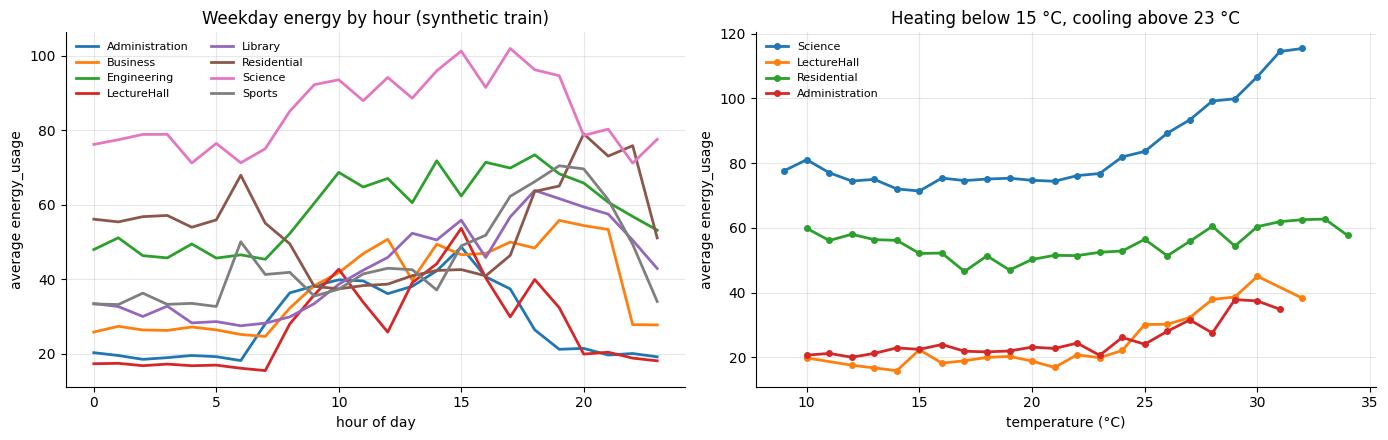

situations in the test period (from test_answers.csv):
situation
rain             1078
normal            919
break             559
exams             165
heatwave          136
cold snap          83
holiday            36
equipment run      23
special event       1


In [4]:
everything = train.merge(answers[['id']], how='left', on='id')     # train rows only have answers in train.csv
weekday = train[~train['day_of_week'].isin(['Saturday', 'Sunday'])]

fig, (left, right) = plt.subplots(1, 2, figsize=(14, 4.5))
for building_type, rows in weekday.groupby('building_type'):
    left.plot(rows.groupby('hour')['energy_usage'].mean(), linewidth=2, label=building_type)
left.set(title='Weekday energy by hour (synthetic train)', xlabel='hour of day', ylabel='average energy_usage')
left.legend(fontsize=8, ncol=2, frameon=False)

temperature_bins = train['temperature'].round()
for building_type in ['Science', 'LectureHall', 'Residential', 'Administration']:
    rows = train[train['building_type'] == building_type]
    curve = rows.groupby(temperature_bins[rows.index])['energy_usage'].mean()
    counts = rows.groupby(temperature_bins[rows.index]).size()
    right.plot(curve[counts >= 10], linewidth=2, marker='o', markersize=4, label=building_type)
right.set(title='Heating below 15 °C, cooling above 23 °C', xlabel='temperature (°C)', ylabel='average energy_usage')
right.legend(fontsize=8, frameon=False)
for axis in (left, right):
    axis.grid(alpha=0.3)
    axis.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('situations in the test period (from test_answers.csv):')
print(answers['situation'].value_counts().to_string())

## 2. The models
Every model is trained on the synthetic `train.csv` only and scored on all 3,000 synthetic test rows.

| model | what it does | uses test inputs? |
|---|---|---|
| previous hour | prediction = `previous_usage` (typical value for that building and hour when blank) | no |
| simple LightGBM | one LightGBM on the raw columns; LightGBM handles blanks itself | no |
| clean model | our recipe with every use of `test.csv` removed (`clean_model.py`, weight 0.45) | no |
| v4 | 0.25 × v3 notebook model + 0.75 × per-missing-pattern models | yes (imputer and weights) |
| LightGBM-imputed model | LightGBM imputers + Ridge/boosting, averaged over 10 seeds | yes (imputers) |
| **best_model recipe** | 0.25 × v4 + 0.75 × LightGBM-imputed model (seed 527) | yes |
| **candidate_final recipe** | 0.30 × v4 + 0.70 × LightGBM-imputed model (10 seeds) | yes |

Nothing was tuned for this data. The settings (thresholds such as heat ≥ 33.5 °C, weights, tree sizes) are the ones chosen on the real competition data, so this checks whether the **recipe** carries over to a campus it has never seen.

In [5]:
def rmse(errors):
    return float(np.sqrt(np.mean(np.square(errors))))

predictions = {}                 # model name -> {'test': ..., 'test without blanks': ...}
frames = {'test': test_inputs, 'test without blanks': test_without_blanks}

# previous hour
typical_energy = (train.assign(weekend=train['day_of_week'].isin(['Saturday', 'Sunday']))
                  .groupby(['building_id', 'hour', 'weekend'])['energy_usage'].median())
def previous_hour_guess(rows):
    keys = pd.MultiIndex.from_arrays([rows['building_id'], rows['hour'], rows['day_of_week'].isin(['Saturday', 'Sunday'])])
    typical = typical_energy.reindex(keys).to_numpy()
    return np.where(rows['previous_usage'].isna(), typical, rows['previous_usage'])
predictions['previous hour'] = {name: previous_hour_guess(rows) for name, rows in frames.items()}

# simple LightGBM
def raw_columns(rows):
    columns = rows[['hour', 'month'] + NUMERIC_COLUMNS].copy()
    columns['day'] = rows['day_of_week'].map(DAY_NUMBER)
    columns['building_id'] = pd.Categorical(rows['building_id'], categories=BUILDING_IDS)
    columns['building_type'] = pd.Categorical(rows['building_type'], categories=BUILDING_TYPES)
    return columns
simple = lightgbm.LGBMRegressor(n_estimators=1500, learning_rate=0.02, num_leaves=31, min_child_samples=20, subsample=0.8,
                                subsample_freq=1, colsample_bytree=0.8, random_state=0, verbose=-1, n_jobs=CPU_THREADS)
simple.fit(raw_columns(train), train['energy_usage'])
predictions['simple LightGBM'] = {name: simple.predict(raw_columns(rows)) for name, rows in frames.items()}
print('baselines done')

baselines done


In [6]:
# clean model: our recipe, learning from train.csv only
from clean_model import fit_predict_A, fit_predict_B

started = time.time()
with threadpool_limits(limits=CPU_THREADS):
    clean_v4 = fit_predict_A(train, list(frames.values()))
    clean_lightgbm = fit_predict_B(train, list(frames.values()))
predictions['clean model'] = {name: 0.55 * a + 0.45 * b for name, a, b in zip(frames, clean_v4, clean_lightgbm)}
print(f'clean model done [{time.time() - started:.0f}s]')

clean model done [53s]


In [7]:
# our full recipe: the exact model code from candidate_final_pipeline.ipynb
# (cells 2, 3, 4 and 6 only define functions and classes: event types, v3 model, pattern models, LightGBM-imputed model)
pipeline = json.load(open(PROJECT_FOLDER / 'candidate_final_pipeline.ipynb'))
code_cells = [''.join(cell['source']) for cell in pipeline['cells'] if cell['cell_type'] == 'code']
for number in [2, 3, 4, 6]:
    exec(code_cells[number], globals())

started = time.time()
with threadpool_limits(limits=CPU_THREADS):
    v3_model = V3NotebookModel().fit(train)
    pattern_models = MissingPatternModels().fit(train, test_inputs)
    v4 = {name: 0.25 * v3_model.predict(rows) + 0.75 * pattern_models.predict(rows) for name, rows in frames.items()}
    print(f'v4 done [{time.time() - started:.0f}s]')

    per_seed = []
    for seed in RANDOM_SEEDS:
        model = LightGBMImputedModel(seed=seed).fit(train, test_inputs)
        per_seed.append({name: model.predict(rows) for name, rows in frames.items()})
    print(f'LightGBM-imputed model, {len(RANDOM_SEEDS)} seeds done [{time.time() - started:.0f}s]')

lightgbm_imputed = {name: np.mean([seed_result[name] for seed_result in per_seed], axis=0) for name in frames}
predictions['v4'] = v4
predictions['LightGBM-imputed model'] = lightgbm_imputed
predictions['best_model recipe'] = {name: 0.25 * v4[name] + 0.75 * per_seed[0][name] for name in frames}
predictions['candidate_final recipe'] = {name: 0.30 * v4[name] + 0.70 * lightgbm_imputed[name] for name in frames}

unusual event rows: train 13.0% | test 15.6%
v4 done [28s]
LightGBM-imputed model, 10 seeds done [251s]


## 3. Results (RMSE, lower is better)
* **all test rows**: the score the hidden leaderboard would give.
* **rows without / with blanks**: where each model loses its points.
* **if no sensor had failed**: the same models fed the true values behind every blank (only possible on synthetic data). The gap to "all test rows" is what the blanks cost.
* **best possible**: the noise-free value from the simulator. Even a perfect model can't go below this, because the meter noise is random.

In [8]:
rows = {}
for name, prediction in predictions.items():
    error = prediction['test'] - true_energy
    rows[name] = {'all test rows': rmse(error),
                  'rows without blanks': rmse(error[~test_has_blank]),
                  'rows with blanks': rmse(error[test_has_blank]),
                  'if no sensor had failed': rmse(prediction['test without blanks'] - true_energy)}
noise = answers['expected_energy'].to_numpy() - true_energy
rows['best possible (noise floor)'] = {'all test rows': rmse(noise), 'rows without blanks': rmse(noise[~test_has_blank]),
                                       'rows with blanks': rmse(noise[test_has_blank]), 'if no sensor had failed': rmse(noise)}
results = pd.DataFrame(rows).T
results.to_csv(DATA_FOLDER / 'benchmark_results.csv')
results.round(3)

,all test rows,rows without blanks,rows with blanks,if no sensor had failed
previous hour,7.722,7.341,8.759,7.268
simple LightGBM,4.780,4.080,6.429,4.037
clean model,4.699,4.453,5.364,4.411
v4,4.842,4.661,5.344,4.618
LightGBM-imputed model,4.829,4.671,5.273,4.601
best_model recipe,4.727,4.585,5.126,4.512
candidate_final recipe,4.712,4.565,5.126,4.495
best possible (noise floor),1.677,1.684,1.655,1.677


In [9]:
# error by situation (situations are from test_answers.csv; models never see them)
by_situation = {}
for name in ['previous hour', 'simple LightGBM', 'clean model', 'candidate_final recipe']:
    error = pd.Series(predictions[name]['test'] - true_energy)
    by_situation[name] = error.groupby(answers['situation']).apply(rmse)
table = pd.DataFrame(by_situation)
table.insert(0, 'test rows', answers['situation'].value_counts())
table.sort_values('test rows', ascending=False).round(2)

,test rows,previous hour,simple LightGBM,clean model,candidate_final recipe
situation,,,,,
rain,1078,6.85,4.37,4.10,4.12
normal,919,8.67,4.53,4.62,4.77
break,559,7.02,4.65,4.32,4.14
exams,165,5.96,4.67,4.55,4.60
heatwave,136,9.17,5.15,5.42,5.45
cold snap,83,9.77,6.34,6.37,6.55
holiday,36,5.78,2.97,3.41,3.67
equipment run,23,14.96,16.32,17.17,16.41
special event,1,2.20,3.36,6.06,4.89


In [10]:
# save every model's predictions next to the answers, for your own checks
saved = pd.DataFrame({'id': test['id'], 'energy_usage': true_energy})
for name, prediction in predictions.items():
    saved[name] = prediction['test']
saved.to_csv(DATA_FOLDER / 'benchmark_predictions.csv', index=False)
print(f'wrote benchmark_results.csv and benchmark_predictions.csv ({len(saved):,} rows)')

wrote benchmark_results.csv and benchmark_predictions.csv (3,000 rows)


## 4. What this shows (numbers from the run above)

1. **Scores on all 3,000 test rows:** candidate_final recipe 4.71, clean model 4.70, simple LightGBM 4.78, previous-hour guess 7.72. The "best possible" 1.68 knows the hidden equipment runs and drift, so no real model can reach it. The 23 hidden equipment-run rows alone are 9% of our squared error.
2. **Our handling of blanks carries over to a new campus.** On rows with blanks we score 5.13, vs 6.43 for the simple LightGBM. Blanks cost us only 4.50 → 4.71, vs 4.04 → 4.78 for the simple LightGBM. The imputers and per-pattern models are a real gain, not leaderboard luck.
3. **Our hand-made features do not carry over.** On rows without blanks the simple LightGBM wins (4.08 vs 4.57). Our models are mostly Ridge with straight-line temperature effects, designed for the real campus (always 23–36 °C, cooling only). Here the campus needs heating *and* cooling, a U-shape that trees fit more easily. That's expected: hand-made features fit one campus. It doesn't hurt the competition, because the hidden test comes from the real campus, where Ridge beat trees in every check.
4. **Using test inputs neither helped nor hurt here:** 4.712 (uses test inputs) vs 4.699 (clean). The gap is within noise (bootstrap 95% range −0.05 to +0.08), so there's no sign of overfitting from it.
5. **Don't tune the competition model on this data.** It's a different campus on purpose. Use it to check that a change doesn't break on unseen data, and to measure things the leaderboard can't. For example, the `*_true` columns in `test_answers.csv` show how accurate each imputer is.